In [39]:
# ============================================================
# RETINA-XAI V2 — IMPORTS
# ============================================================

from pathlib import Path
import time
import random

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from matplotlib.patches import Rectangle

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.14.0+cpu
CUDA available: False


In [40]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(
    r"C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening"
)

SEG_ROOT = (
    PROJECT_ROOT
    / "Disease Dataset"
    / "A. Segmentation"
)

TRAIN_IMG_DIR = (
    SEG_ROOT
    / "1. Original Images"
    / "a. Training Set"
)

TRAIN_MASK_ROOT = (
    SEG_ROOT
    / "2. All Segmentation Groundtruths"
    / "a. Training Set"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "deep-learning"
    / "models"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "segmentation_v2"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

V2_MODEL_PATH = (
    MODEL_DIR
    / "retina_xai_unet_v2.pth"
)

PATCH_SIZE = 512

MIN_LESION_PIXELS = 50

BACKGROUND_PATCHES_PER_IMAGE = 4

BATCH_SIZE = 2

NUM_EPOCHS = 10

LEARNING_RATE = 1e-4


print("================================================")
print("RETINA-XAI V2 CONFIGURATION")
print("================================================")

print("Image directory :", TRAIN_IMG_DIR)
print("Mask directory  :", TRAIN_MASK_ROOT)
print("Model path      :", V2_MODEL_PATH)
print("Output directory:", OUTPUT_DIR)

print()
print("Patch size      :", PATCH_SIZE)
print("Min lesion px   :", MIN_LESION_PIXELS)
print("Batch size      :", BATCH_SIZE)
print("Epochs          :", NUM_EPOCHS)
print("Learning rate   :", LEARNING_RATE)

RETINA-XAI V2 CONFIGURATION
Image directory : C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\Disease Dataset\A. Segmentation\1. Original Images\a. Training Set
Mask directory  : C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\Disease Dataset\A. Segmentation\2. All Segmentation Groundtruths\a. Training Set
Model path      : C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\deep-learning\models\retina_xai_unet_v2.pth
Output directory: C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\outputs\segmentation_v2

Patch size      : 512
Min lesion px   : 50
Batch size      : 2
Epochs          : 10
Learning rate   : 0.0001


In [41]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(
    r"C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening"
)

SEG_ROOT = (
    PROJECT_ROOT
    / "Disease Dataset"
    / "A. Segmentation"
)

TRAIN_IMG_DIR = (
    SEG_ROOT
    / "1. Original Images"
    / "a. Training Set"
)

TRAIN_MASK_ROOT = (
    SEG_ROOT
    / "2. All Segmentation Groundtruths"
    / "a. Training Set"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "deep-learning"
    / "models"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "segmentation_v2"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

V2_MODEL_PATH = (
    MODEL_DIR
    / "retina_xai_unet_v2.pth"
)

PATCH_SIZE = 512

MIN_LESION_PIXELS = 50

BACKGROUND_PATCHES_PER_IMAGE = 4

BATCH_SIZE = 2

NUM_EPOCHS = 10

LEARNING_RATE = 1e-4


print("================================================")
print("RETINA-XAI V2 CONFIGURATION")
print("================================================")

print("Image directory :", TRAIN_IMG_DIR)
print("Mask directory  :", TRAIN_MASK_ROOT)
print("Model path      :", V2_MODEL_PATH)
print("Output directory:", OUTPUT_DIR)

print()
print("Patch size      :", PATCH_SIZE)
print("Min lesion px   :", MIN_LESION_PIXELS)
print("Batch size      :", BATCH_SIZE)
print("Epochs          :", NUM_EPOCHS)
print("Learning rate   :", LEARNING_RATE)

RETINA-XAI V2 CONFIGURATION
Image directory : C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\Disease Dataset\A. Segmentation\1. Original Images\a. Training Set
Mask directory  : C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\Disease Dataset\A. Segmentation\2. All Segmentation Groundtruths\a. Training Set
Model path      : C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\deep-learning\models\retina_xai_unet_v2.pth
Output directory: C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\outputs\segmentation_v2

Patch size      : 512
Min lesion px   : 50
Batch size      : 2
Epochs          : 10
Learning rate   : 0.0001


In [42]:
# ============================================================
# LESION CLASSES
# ============================================================

CLASS_NAMES = [
    "Background",
    "Microaneurysms",
    "Haemorrhages",
    "Hard Exudates",
    "Soft Exudates"
]

MASK_FOLDERS = {
    1: "1. Microaneurysms",
    2: "2. Haemorrhages",
    3: "3. Hard Exudates",
    4: "4. Soft Exudates"
}

MASK_SUFFIXES = {
    1: "MA",
    2: "HE",
    3: "EX",
    4: "SE"
}

print("Classes:")

for i, name in enumerate(CLASS_NAMES):
    print(f"{i} → {name}")

print()
print("✅ Lesion configuration ready")

Classes:
0 → Background
1 → Microaneurysms
2 → Haemorrhages
3 → Hard Exudates
4 → Soft Exudates

✅ Lesion configuration ready


In [43]:
# ============================================================
# COMBINED MASK LOADER
# ============================================================

def load_combined_mask(image_name):

    base_name = Path(
        image_name
    ).stem

    image_path = (
        TRAIN_IMG_DIR
        / image_name
    )

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    if image is None:
        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )

    h, w = image.shape[:2]

    combined = np.zeros(
        (h, w),
        dtype=np.uint8
    )

    for class_id, folder_name in MASK_FOLDERS.items():

        suffix = MASK_SUFFIXES[class_id]

        mask_path = (
            TRAIN_MASK_ROOT
            / folder_name
            / f"{base_name}_{suffix}.tif"
        )

        if mask_path.exists():

            lesion_mask = cv2.imread(
                str(mask_path),
                cv2.IMREAD_GRAYSCALE
            )

            if lesion_mask is not None:

                combined[
                    lesion_mask > 0
                ] = class_id

    return combined


# Test
test_mask = load_combined_mask(
    "IDRiD_01.jpg"
)

print("Test mask shape:", test_mask.shape)

classes, counts = np.unique(
    test_mask,
    return_counts=True
)

for cls, count in zip(classes, counts):

    print(
        f"{CLASS_NAMES[cls]:20s}: "
        f"{count:,} pixels"
    )

print("✅ Mask loader working")

Test mask shape: (2848, 4288)
Background          : 12,056,567 pixels
Microaneurysms      : 6,941 pixels
Haemorrhages        : 35,430 pixels
Hard Exudates       : 113,286 pixels
✅ Mask loader working


In [44]:
# ============================================================
# IMAGE-LEVEL TRAIN / VALIDATION SPLIT
# ============================================================

all_images = sorted([
    p.name
    for p in TRAIN_IMG_DIR.glob("*.jpg")
])

print("Total images:", len(all_images))

train_images, val_images = train_test_split(
    all_images,
    test_size=0.20,
    random_state=42
)

print()
print("Training images  :", len(train_images))
print("Validation images:", len(val_images))

print()
print("Important: split is performed BEFORE patch extraction.")
print("This prevents patches from the same retina")
print("appearing in both train and validation.")

print()
print("✅ Image split ready")

Total images: 54

Training images  : 43
Validation images: 11

Important: split is performed BEFORE patch extraction.
This prevents patches from the same retina
appearing in both train and validation.

✅ Image split ready


In [45]:
# ============================================================
# LESION-AWARE PATCH INDEX
# ============================================================

def build_patch_index(
    image_names,
    patch_size=512,
    min_lesion_pixels=50,
    background_patches_per_image=4
):

    patch_index = []

    for image_number, image_name in enumerate(
        image_names,
        start=1
    ):

        print(
            f"\rProcessing "
            f"{image_number}/{len(image_names)}: "
            f"{image_name}",
            end=""
        )

        image_path = (
            TRAIN_IMG_DIR
            / image_name
        )

        image = cv2.imread(
            str(image_path),
            cv2.IMREAD_COLOR
        )

        if image is None:
            continue

        mask = load_combined_mask(
            image_name
        )

        h, w = mask.shape

        lesion_candidates = []

        background_candidates = []

        for y in range(
            0,
            h - patch_size + 1,
            patch_size
        ):

            for x in range(
                0,
                w - patch_size + 1,
                patch_size
            ):

                mask_patch = mask[
                    y:y + patch_size,
                    x:x + patch_size
                ]

                lesion_pixels = int(
                    np.sum(mask_patch > 0)
                )

                patch = {
                    "image_name": image_name,
                    "x": x,
                    "y": y,
                    "lesion_pixels": lesion_pixels
                }

                if lesion_pixels >= min_lesion_pixels:

                    lesion_candidates.append(
                        patch
                    )

                else:

                    background_candidates.append(
                        patch
                    )

        # Keep every lesion patch
        patch_index.extend(
            lesion_candidates
        )

        # Random background samples
        rng = np.random.default_rng(
            42 + image_number
        )

        if len(background_candidates) > background_patches_per_image:

            selected = rng.choice(
                len(background_candidates),
                size=background_patches_per_image,
                replace=False
            )

            background_candidates = [
                background_candidates[i]
                for i in selected
            ]

        patch_index.extend(
            background_candidates
        )

    print()

    return patch_index


train_patch_index = build_patch_index(
    train_images,
    patch_size=PATCH_SIZE,
    min_lesion_pixels=MIN_LESION_PIXELS,
    background_patches_per_image=BACKGROUND_PATCHES_PER_IMAGE
)

val_patch_index = build_patch_index(
    val_images,
    patch_size=PATCH_SIZE,
    min_lesion_pixels=MIN_LESION_PIXELS,
    background_patches_per_image=BACKGROUND_PATCHES_PER_IMAGE
)

print()
print("=" * 55)
print("PATCH DATASET")
print("=" * 55)

print(
    "Training patches  :",
    len(train_patch_index)
)

print(
    "Validation patches:",
    len(val_patch_index)
)

Processing 43/43: IDRiD_39.jpg
Processing 11/11: IDRiD_14.jpg

PATCH DATASET
Training patches  : 1140
Validation patches: 337


In [46]:
# ============================================================
# PATCH DISTRIBUTION
# ============================================================

def analyze_patch_index(
    patch_index,
    name
):

    lesion = [
        p for p in patch_index
        if p["lesion_pixels"] >= MIN_LESION_PIXELS
    ]

    background = [
        p for p in patch_index
        if p["lesion_pixels"] < MIN_LESION_PIXELS
    ]

    print()
    print(name)
    print("-" * 45)

    print(
        "Total patches      :",
        len(patch_index)
    )

    print(
        "Lesion patches     :",
        len(lesion)
    )

    print(
        "Background patches :",
        len(background)
    )

    if lesion:

        values = [
            p["lesion_pixels"]
            for p in lesion
        ]

        print(
            "Min lesion pixels  :",
            min(values)
        )

        print(
            "Max lesion pixels  :",
            max(values)
        )

        print(
            "Average lesion px  :",
            round(np.mean(values), 2)
        )


analyze_patch_index(
    train_patch_index,
    "TRAINING"
)

analyze_patch_index(
    val_patch_index,
    "VALIDATION"
)


TRAINING
---------------------------------------------
Total patches      : 1140
Lesion patches     : 968
Background patches : 172
Min lesion pixels  : 54
Max lesion pixels  : 219682
Average lesion px  : 10462.13

VALIDATION
---------------------------------------------
Total patches      : 337
Lesion patches     : 293
Background patches : 44
Min lesion pixels  : 53
Max lesion pixels  : 71210
Average lesion px  : 8560.91


In [47]:
# ============================================================
# PYTORCH V2 PATCH DATASET
# ============================================================

class IDRiDV2PatchDataset(Dataset):

    def __init__(
        self,
        patch_index,
        augment=False
    ):

        self.patch_index = patch_index
        self.augment = augment

    def __len__(self):

        return len(
            self.patch_index
        )

    def __getitem__(self, idx):

        item = self.patch_index[idx]

        image_name = item[
            "image_name"
        ]

        x = item["x"]
        y = item["y"]

        # ----------------------------
        # Image
        # ----------------------------

        image_path = (
            TRAIN_IMG_DIR
            / image_name
        )

        image = cv2.imread(
            str(image_path),
            cv2.IMREAD_COLOR
        )

        if image is None:
            raise FileNotFoundError(
                image_path
            )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # ----------------------------
        # Mask
        # ----------------------------

        mask = load_combined_mask(
            image_name
        )

        # ----------------------------
        # Crop
        # ----------------------------

        image = image[
            y:y + PATCH_SIZE,
            x:x + PATCH_SIZE
        ]

        mask = mask[
            y:y + PATCH_SIZE,
            x:x + PATCH_SIZE
        ]

        # ----------------------------
        # Augmentation
        # ----------------------------

        if self.augment:

            if np.random.random() < 0.5:

                image = np.fliplr(
                    image
                ).copy()

                mask = np.fliplr(
                    mask
                ).copy()

            if np.random.random() < 0.5:

                image = np.flipud(
                    image
                ).copy()

                mask = np.flipud(
                    mask
                ).copy()

            if np.random.random() < 0.5:

                k = np.random.randint(
                    1,
                    4
                )

                image = np.rot90(
                    image,
                    k
                ).copy()

                mask = np.rot90(
                    mask,
                    k
                ).copy()

        # ----------------------------
        # Image tensor
        # ----------------------------

        image = (
            image.astype(
                np.float32
            ) / 255.0
        )

        image = torch.from_numpy(
            image
        ).permute(
            2,
            0,
            1
        ).float()

        # ----------------------------
        # Mask tensor
        # ----------------------------

        mask = torch.from_numpy(
            mask.astype(
                np.int64
            )
        )

        return image, mask


print("✅ Dataset class created")

✅ Dataset class created


In [48]:
# ============================================================
# DATASETS + DATALOADERS
# ============================================================

train_dataset = IDRiDV2PatchDataset(
    train_patch_index,
    augment=True
)

val_dataset = IDRiDV2PatchDataset(
    val_patch_index,
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("Training samples  :", len(train_dataset))
print("Validation samples:", len(val_dataset))

print()
print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))

print("✅ DataLoaders ready")

Training samples  : 1140
Validation samples: 337

Training batches  : 570
Validation batches: 169
✅ DataLoaders ready


In [49]:
# ============================================================
# BATCH SANITY CHECK
# ============================================================

images, masks = next(
    iter(train_loader)
)

print("Images shape:", images.shape)
print("Masks shape :", masks.shape)

print(
    "Image range:",
    images.min().item(),
    "to",
    images.max().item()
)

print(
    "Mask classes:",
    torch.unique(
        masks
    ).tolist()
)

Images shape: torch.Size([2, 3, 512, 512])
Masks shape : torch.Size([2, 512, 512])
Image range: 0.0117647061124444 to 0.9843137264251709
Mask classes: [0, 1, 2, 3, 4]


In [50]:
# ============================================================
# U-NET V2
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):

        return self.block(x)


class UNetV2(nn.Module):

    def __init__(
        self,
        num_classes=5
    ):

        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(
            3,
            32
        )

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.enc4 = DoubleConv(
            128,
            256
        )

        self.pool = nn.MaxPool2d(
            2
        )

        # Bottleneck
        self.bottleneck = DoubleConv(
            256,
            512
        )

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            512,
            256,
            2,
            2
        )

        self.dec4 = DoubleConv(
            512,
            256
        )

        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            2,
            2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            2,
            2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            2,
            2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        # Output
        self.final = nn.Conv2d(
            32,
            num_classes,
            1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        b = self.bottleneck(
            self.pool(e4)
        )

        d4 = self.up4(b)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)

        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return self.final(d1)


print("✅ U-Net V2 class created")

✅ U-Net V2 class created


In [51]:
# ============================================================
# MODEL
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model_v2 = UNetV2(
    num_classes=5
).to(device)

print("Device:", device)

images, masks = next(
    iter(train_loader)
)

images = images.to(device)

with torch.no_grad():

    outputs = model_v2(
        images
    )

print()
print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

print()
print("Expected output:")
print("[batch, 5, 512, 512]")

Device: cpu

Input shape : torch.Size([2, 3, 512, 512])
Output shape: torch.Size([2, 5, 512, 512])

Expected output:
[batch, 5, 512, 512]


In [52]:
# ============================================================
# V2 LESION-FOCUSED LOSS
# ============================================================

class FocalLossV2(nn.Module):

    def __init__(
        self,
        alpha=None,
        gamma=2.0
    ):

        super().__init__()

        self.gamma = gamma

        if alpha is not None:

            self.register_buffer(
                "alpha",
                alpha.detach().clone().float()
            )

        else:

            self.alpha = None

    def forward(
        self,
        logits,
        targets
    ):

        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction="none"
        )

        pt = torch.exp(
            -ce
        )

        focal = (
            (1.0 - pt)
            ** self.gamma
        ) * ce

        return focal.mean()


class LesionDiceLossV2(nn.Module):

    def __init__(
        self,
        num_classes=5,
        smooth=1e-6
    ):

        super().__init__()

        self.num_classes = num_classes
        self.smooth = smooth

    def forward(
        self,
        logits,
        targets
    ):

        probs = F.softmax(
            logits,
            dim=1
        )

        total_loss = 0.0

        # Ignore background
        for class_id in range(
            1,
            self.num_classes
        ):

            pred = probs[
                :,
                class_id
            ]

            target = (
                targets == class_id
            ).float()

            intersection = (
                pred * target
            ).sum()

            denominator = (
                pred.sum()
                +
                target.sum()
            )

            dice = (
                2.0 * intersection
                +
                self.smooth
            ) / (
                denominator
                +
                self.smooth
            )

            total_loss += (
                1.0 - dice
            )

        return (
            total_loss
            /
            (self.num_classes - 1)
        )


# Class weights
class_weights = torch.tensor(
    [
        0.05,
        3.0,
        1.5,
        1.5,
        2.5
    ],
    dtype=torch.float32,
    device=device
)


criterion_focal = FocalLossV2(
    alpha=class_weights,
    gamma=2.0
).to(device)


criterion_dice = LesionDiceLossV2(
    num_classes=5
).to(device)


def v2_loss(
    logits,
    targets
):

    focal = criterion_focal(
        logits,
        targets
    )

    dice = criterion_dice(
        logits,
        targets
    )

    return (
        0.5 * focal
        +
        0.5 * dice
    )


print("✅ V2 loss ready")
print(
    "Class weights:",
    class_weights.tolist()
)

✅ V2 loss ready
Class weights: [0.05000000074505806, 3.0, 1.5, 1.5, 2.5]


In [53]:
# ============================================================
# LOSS SANITY CHECK
# ============================================================

images, masks = next(
    iter(train_loader)
)

images = images.to(device)
masks = masks.to(device)

outputs = model_v2(
    images
)

loss = v2_loss(
    outputs,
    masks
)

print("Output shape:", outputs.shape)
print("Target shape:", masks.shape)

print(
    "Target classes:",
    torch.unique(
        masks
    ).tolist()
)

print(
    "Initial V2 loss:",
    loss.item()
)

print("✅ Loss sanity check passed")

Output shape: torch.Size([2, 5, 512, 512])
Target shape: torch.Size([2, 512, 512])
Target classes: [0, 1]
Initial V2 loss: 0.5027661919593811
✅ Loss sanity check passed


In [54]:
# ============================================================
# OPTIMIZER + TRAINING CONFIGURATION
# ============================================================

optimizer = torch.optim.Adam(
    model_v2.parameters(),
    lr=LEARNING_RATE
)

best_val_loss = float("inf")

training_history = []

print("Device       :", device)
print("Epochs       :", NUM_EPOCHS)
print("Batch size   :", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Model path   :", V2_MODEL_PATH)

print()
print("✅ Training configuration ready")

Device       : cpu
Epochs       : 10
Batch size   : 2
Learning rate: 0.0001
Model path   : C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\deep-learning\models\retina_xai_unet_v2.pth

✅ Training configuration ready


In [55]:
import os

MODEL_SAVE_PATH = r"C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\deep-learning\models\retina_xai_unet_v2.pth"

print("Model exists:", os.path.exists(MODEL_SAVE_PATH))
print("Model path:", MODEL_SAVE_PATH)

Model exists: True
Model path: C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\deep-learning\models\retina_xai_unet_v2.pth


In [58]:
import torch

MODEL_SAVE_PATH = r"C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\deep-learning\models\retina_xai_unet_v2.pth"

checkpoint = torch.load(
    MODEL_SAVE_PATH,
    map_location="cpu"
)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nFirst 30 saved keys:")
    for i, key in enumerate(checkpoint.keys()):
        print(i, key)
        if i >= 29:
            break

Checkpoint type: <class 'collections.OrderedDict'>

First 30 saved keys:
0 enc1.block.0.weight
1 enc1.block.1.weight
2 enc1.block.1.bias
3 enc1.block.1.running_mean
4 enc1.block.1.running_var
5 enc1.block.1.num_batches_tracked
6 enc1.block.3.weight
7 enc1.block.4.weight
8 enc1.block.4.bias
9 enc1.block.4.running_mean
10 enc1.block.4.running_var
11 enc1.block.4.num_batches_tracked
12 enc2.block.0.weight
13 enc2.block.1.weight
14 enc2.block.1.bias
15 enc2.block.1.running_mean
16 enc2.block.1.running_var
17 enc2.block.1.num_batches_tracked
18 enc2.block.3.weight
19 enc2.block.4.weight
20 enc2.block.4.bias
21 enc2.block.4.running_mean
22 enc2.block.4.running_var
23 enc2.block.4.num_batches_tracked
24 enc3.block.0.weight
25 enc3.block.1.weight
26 enc3.block.1.bias
27 enc3.block.1.running_mean
28 enc3.block.1.running_var
29 enc3.block.1.num_batches_tracked


In [60]:
import torch
import torch.nn as nn
import os

device = torch.device("cpu")

# ==========================================
# EXACT V2 ARCHITECTURE
# ==========================================

class DoubleConvV2(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNetV2(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConvV2(3, 32)
        self.enc2 = DoubleConvV2(32, 64)
        self.enc3 = DoubleConvV2(64, 128)
        self.enc4 = DoubleConvV2(128, 256)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConvV2(256, 512)

        # Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = DoubleConvV2(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConvV2(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConvV2(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConvV2(64, 32)

        self.final = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)


# ==========================================
# LOAD CHECKPOINT
# ==========================================

MODEL_SAVE_PATH = r"C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\deep-learning\models\retina_xai_unet_v2.pth"

print("Model exists:", os.path.exists(MODEL_SAVE_PATH))

model = UNetV2(num_classes=5).to(device)

checkpoint = torch.load(
    MODEL_SAVE_PATH,
    map_location=device
)

model.load_state_dict(checkpoint)
model.eval()

print("\n========================================")
print("✅ V2 BEST MODEL LOADED SUCCESSFULLY")
print("========================================")
print("Device:", device)

Model exists: True

✅ V2 BEST MODEL LOADED SUCCESSFULLY
Device: cpu


In [62]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ============================================================
# PATHS
# ============================================================

IMAGE_PATH = r"C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\Disease Dataset\A. Segmentation\1. Original Images\a. Training Set\IDRiD_01.jpg"

OUTPUT_DIR = r"C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\outputs\segmentation_v2"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Image exists:", os.path.exists(IMAGE_PATH))
print("Image:", IMAGE_PATH)

Image exists: True
Image: C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\Disease Dataset\A. Segmentation\1. Original Images\a. Training Set\IDRiD_01.jpg


In [64]:
PATCH_SIZE = 512

image = cv2.imread(IMAGE_PATH)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

H, W = image.shape[:2]

full_prediction = np.zeros((H, W), dtype=np.uint8)

model.eval()

with torch.no_grad():
    for y in range(0, H, PATCH_SIZE):
        for x in range(0, W, PATCH_SIZE):

            y2 = min(y + PATCH_SIZE, H)
            x2 = min(x + PATCH_SIZE, W)

            patch = image[y:y2, x:x2]

            ph, pw = patch.shape[:2]

            padded = np.zeros(
                (PATCH_SIZE, PATCH_SIZE, 3),
                dtype=np.uint8
            )

            padded[:ph, :pw] = patch

            tensor = torch.from_numpy(
                padded.astype(np.float32) / 255.0
            ).permute(2, 0, 1).unsqueeze(0).to(device)

            output = model(tensor)

            pred = torch.argmax(
                output, dim=1
            )[0].cpu().numpy()

            full_prediction[y:y2, x:x2] = pred[:ph, :pw]

print("✅ Full image prediction completed")
print("Image size:", W, "x", H)
print("Predicted classes:", np.unique(full_prediction))

✅ Full image prediction completed
Image size: 4288 x 2848
Predicted classes: [0 1 2 3 4]


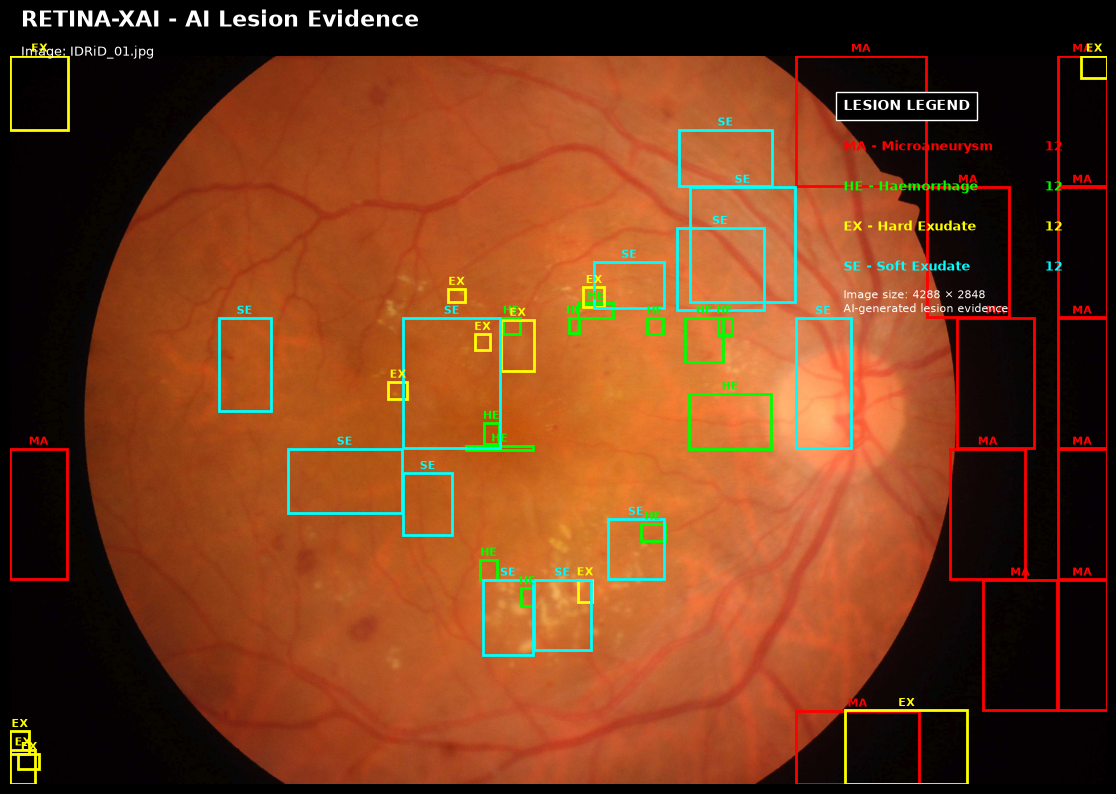

✅ CLEAN LESION EVIDENCE CREATED
Saved:
C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\outputs\segmentation_v2\IDRiD_01_V2_AI_Lesion_Evidence_CLEAN.jpg

Detected regions:
MA: 12
HE: 12
EX: 12
SE: 12


In [67]:
# ============================================================
# RETINA-XAI V2 — CLEAN LESION EVIDENCE
# Similar to Ground Truth visualization
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

CLASS_INFO = {
    1: ("MA", "Microaneurysm"),
    2: ("HE", "Haemorrhage"),
    3: ("EX", "Hard Exudate"),
    4: ("SE", "Soft Exudate")
}

# Minimum area for each lesion
MIN_AREA = {
    1: 20,      # MA
    2: 80,      # HE
    3: 80,      # EX
    4: 80       # SE
}

# Maximum boxes per lesion type
MAX_BOXES = {
    1: 12,
    2: 12,
    3: 12,
    4: 12
}

# ------------------------------------------------------------
# COLORS
# ------------------------------------------------------------

BOX_COLORS = {
    1: "red",       # Microaneurysm
    2: "lime",      # Haemorrhage
    3: "yellow",    # Hard Exudate
    4: "cyan"       # Soft Exudate
}

# ------------------------------------------------------------
# LOAD IMAGE
# ------------------------------------------------------------

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(IMAGE_PATH)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

H, W = image.shape[:2]

# ------------------------------------------------------------
# CREATE FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 8),
    facecolor="black"
)

ax.set_facecolor("black")

ax.imshow(image)

# ============================================================
# DETECT REGIONS
# ============================================================

class_counts = {}

for class_id, (short_name, full_name) in CLASS_INFO.items():

    mask = (
        full_prediction == class_id
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Remove tiny noise
    # --------------------------------------------------------

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # --------------------------------------------------------
    # Connected components
    # --------------------------------------------------------

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )

    regions = []

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        # Minimum area
        if area < MIN_AREA[class_id]:
            continue

        # Ignore extremely large false regions
        if area > 100000:
            continue

        # Ignore very thin noise
        if w < 2 or h < 2:
            continue

        regions.append(
            (area, x, y, w, h)
        )

    # --------------------------------------------------------
    # Keep strongest/largest regions
    # --------------------------------------------------------

    regions = sorted(
        regions,
        key=lambda r: r[0],
        reverse=True
    )

    regions = regions[:MAX_BOXES[class_id]]

    class_counts[class_id] = len(regions)

    # --------------------------------------------------------
    # DRAW BOXES
    # --------------------------------------------------------

    for area, x, y, w, h in regions:

        color = BOX_COLORS[class_id]

        rect = Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            edgecolor=color,
            linewidth=2
        )

        ax.add_patch(rect)

        # Small label
        ax.text(
            x + w / 2,
            y - 6,
            short_name,
            color=color,
            fontsize=8,
            fontweight="bold",
            ha="center",
            va="bottom"
        )


# ============================================================
# TITLE
# ============================================================

ax.text(
    0.01,
    1.04,
    "RETINA-XAI - AI Lesion Evidence",
    transform=ax.transAxes,
    color="white",
    fontsize=16,
    fontweight="bold",
    ha="left"
)

ax.text(
    0.01,
    1.00,
    f"Image: {os.path.basename(IMAGE_PATH)}",
    transform=ax.transAxes,
    color="white",
    fontsize=9,
    ha="left"
)


# ============================================================
# LEGEND
# ============================================================

legend_lines = [
    ("MA", "Microaneurysm", 1),
    ("HE", "Haemorrhage", 2),
    ("EX", "Hard Exudate", 3),
    ("SE", "Soft Exudate", 4)
]

legend_x = 0.76
legend_y = 0.94

# Legend background
ax.text(
    legend_x,
    legend_y,
    "LESION LEGEND",
    transform=ax.transAxes,
    color="white",
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="top",
    bbox=dict(
        facecolor="black",
        edgecolor="white",
        boxstyle="square,pad=0.5"
    )
)

for index, (short_name, full_name, class_id) in enumerate(
    legend_lines
):

    y = legend_y - 0.07 - index * 0.055

    count = class_counts.get(class_id, 0)

    ax.text(
        legend_x,
        y,
        f"{short_name} - {full_name}",
        transform=ax.transAxes,
        color=BOX_COLORS[class_id],
        fontsize=9,
        fontweight="bold",
        ha="left"
    )

    ax.text(
        0.96,
        y,
        str(count),
        transform=ax.transAxes,
        color=BOX_COLORS[class_id],
        fontsize=9,
        fontweight="bold",
        ha="right"
    )


# ============================================================
# IMAGE INFORMATION
# ============================================================

ax.text(
    0.76,
    0.68,
    f"Image size: {W} × {H}\n"
    "AI-generated lesion evidence",
    transform=ax.transAxes,
    color="white",
    fontsize=8,
    ha="left",
    va="top"
)


# ============================================================
# CLEAN DISPLAY
# ============================================================

ax.axis("off")

plt.tight_layout()


# ============================================================
# SAVE JPG
# ============================================================

jpg_path = os.path.join(
    OUTPUT_DIR,
    "IDRiD_01_V2_AI_Lesion_Evidence_CLEAN.jpg"
)

plt.savefig(
    jpg_path,
    format="jpg",
    dpi=200,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

print("==============================================")
print("✅ CLEAN LESION EVIDENCE CREATED")
print("==============================================")
print("Saved:")
print(jpg_path)

print("\nDetected regions:")
print("MA:", class_counts.get(1, 0))
print("HE:", class_counts.get(2, 0))
print("EX:", class_counts.get(3, 0))
print("SE:", class_counts.get(4, 0))

In [69]:
# ============================================================
# RETINA-XAI V2 — FULL IMAGE PREDICTION
# WITH RETINA FIELD-OF-VIEW MASK
# ============================================================

import cv2
import numpy as np
import torch

PATCH_SIZE = 512

# ------------------------------------------------------------
# Load image
# ------------------------------------------------------------

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(IMAGE_PATH)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

H, W = image.shape[:2]

print("Image size:", W, "x", H)

# ------------------------------------------------------------
# Create prediction canvas
# ------------------------------------------------------------

full_prediction = np.zeros(
    (H, W),
    dtype=np.uint8
)

# ============================================================
# CREATE RETINA MASK
# ============================================================

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Fundus is bright, background is dark
retina_mask = (gray > 15).astype(np.uint8) * 255

# Clean mask
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (51, 51)
)

retina_mask = cv2.morphologyEx(
    retina_mask,
    cv2.MORPH_CLOSE,
    kernel
)

retina_mask = cv2.morphologyEx(
    retina_mask,
    cv2.MORPH_OPEN,
    kernel
)

# Keep only largest connected component
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    retina_mask,
    connectivity=8
)

if num_labels > 1:

    largest_component = 1 + np.argmax(
        stats[1:, cv2.CC_STAT_AREA]
    )

    retina_mask = (
        labels == largest_component
    ).astype(np.uint8) * 255


# ============================================================
# PREDICT PATCHES
# ============================================================

model.eval()

with torch.no_grad():

    for y in range(0, H, PATCH_SIZE):

        for x in range(0, W, PATCH_SIZE):

            y2 = min(y + PATCH_SIZE, H)
            x2 = min(x + PATCH_SIZE, W)

            patch = image[y:y2, x:x2]

            ph, pw = patch.shape[:2]

            # ------------------------------------------------
            # Pad edge patch
            # ------------------------------------------------

            padded = np.zeros(
                (PATCH_SIZE, PATCH_SIZE, 3),
                dtype=np.uint8
            )

            padded[:ph, :pw] = patch

            tensor = torch.from_numpy(
                padded.astype(np.float32) / 255.0
            ).permute(2, 0, 1).unsqueeze(0).to(device)

            # ------------------------------------------------
            # Prediction
            # ------------------------------------------------

            output = model(tensor)

            pred = torch.argmax(
                output,
                dim=1
            )[0].cpu().numpy()

            # ------------------------------------------------
            # IMPORTANT:
            # Only copy the ORIGINAL image area
            # Never copy padded area
            # ------------------------------------------------

            full_prediction[
                y:y2,
                x:x2
            ] = pred[:ph, :pw]


# ============================================================
# REMOVE ALL PREDICTIONS OUTSIDE RETINA
# ============================================================

outside_retina = retina_mask == 0

full_prediction[outside_retina] = 0

print("============================================")
print("✅ FULL IMAGE PREDICTION COMPLETE")
print("============================================")

print("Image:", W, "x", H)

print(
    "Retina pixels:",
    np.sum(retina_mask > 0)
)

print(
    "Predicted classes:",
    np.unique(full_prediction)
)

print(
    "Outside-retina predictions removed:",
    np.sum(
        (full_prediction > 0) &
        (retina_mask == 0)
    )
)

Image size: 4288 x 2848
✅ FULL IMAGE PREDICTION COMPLETE
Image: 4288 x 2848
Retina pixels: 8455491
Predicted classes: [0 1 2 3 4]
Outside-retina predictions removed: 0


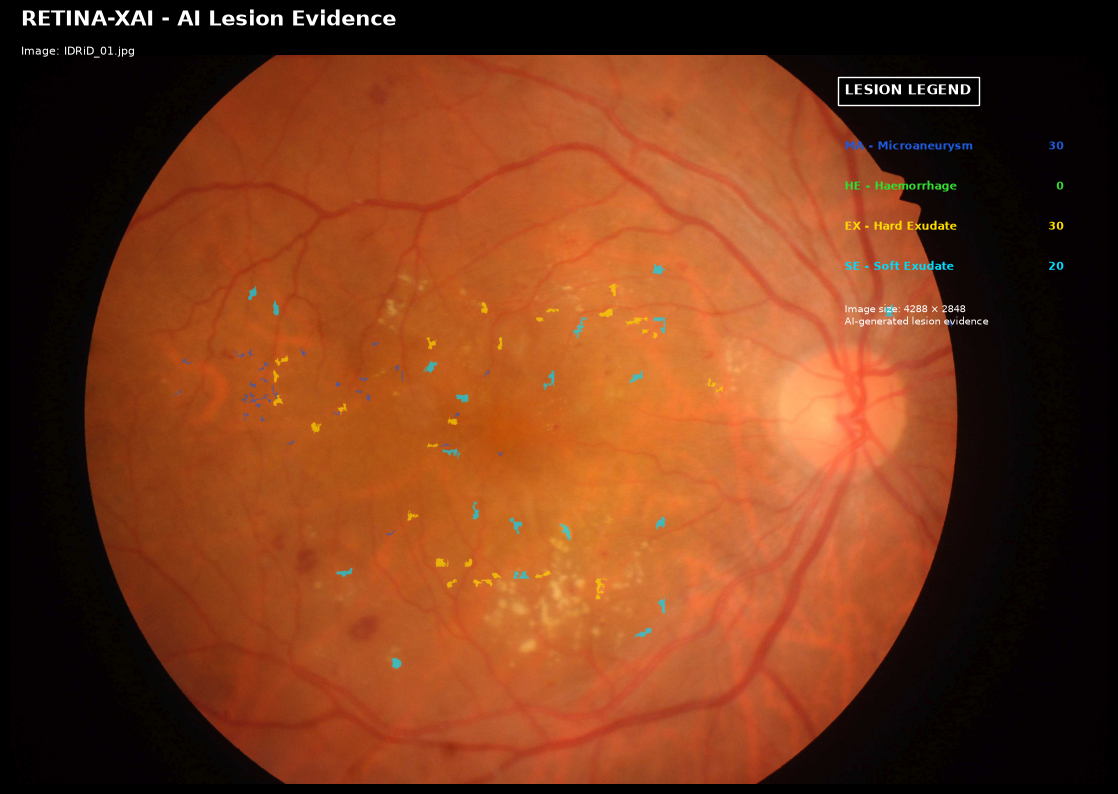

✅ FILLED LESION EVIDENCE CREATED
Microaneurysm : 30
Haemorrhage   : 0
Hard Exudate  : 30
Soft Exudate  : 20

Saved:
C:\Users\vu241\OneDrive\Desktop\Diabetic-Retinopathy-Screening\outputs\segmentation_v2\IDRiD_01_V2_FILLED_Lesion_Evidence.jpg


In [72]:
# ============================================================
# RETINA-XAI V2
# FILLED LESION CONTOURS — NO BOXES
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# LESION CONFIGURATION
# ============================================================

CLASS_INFO = {
    1: ("MA", "Microaneurysm", (30, 90, 220)),   # Blue
    2: ("HE", "Haemorrhage", (50, 220, 50)),     # Green
    3: ("EX", "Hard Exudate", (255, 220, 0)),     # Yellow
    4: ("SE", "Soft Exudate", (0, 220, 255))      # Cyan
}

# ------------------------------------------------------------
# Area filtering
# ------------------------------------------------------------

MIN_AREA = {
    1: 3,
    2: 5,
    3: 5,
    4: 5
}

MAX_AREA = {
    1: 500,
    2: 1200,
    3: 1200,
    4: 1200
}

# Maximum visible lesion regions
MAX_REGIONS = {
    1: 30,
    2: 30,
    3: 30,
    4: 20
}

# ============================================================
# LOAD IMAGE
# ============================================================

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(IMAGE_PATH)

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

H, W = image_rgb.shape[:2]

# ============================================================
# CREATE OVERLAY
# ============================================================

overlay = image_rgb.copy()

class_counts = {}

# ============================================================
# PROCESS EACH LESION CLASS
# ============================================================

for class_id, (short_name, full_name, color_rgb) in CLASS_INFO.items():

    # --------------------------------------------------------
    # Class mask
    # --------------------------------------------------------

    mask = (
        full_prediction == class_id
    ).astype(np.uint8) * 255

    # --------------------------------------------------------
    # Remove everything outside retina
    # --------------------------------------------------------

    mask[retina_mask == 0] = 0

    # --------------------------------------------------------
    # Very small opening
    # Don't use large kernels because lesions are tiny
    # --------------------------------------------------------

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # --------------------------------------------------------
    # Find individual contours
    # --------------------------------------------------------

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    valid_regions = []

    for contour in contours:

        area = cv2.contourArea(contour)

        # Remove tiny noise
        if area < MIN_AREA[class_id]:
            continue

        # Remove huge connected predictions
        if area > MAX_AREA[class_id]:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        # Don't allow huge regions
        if w > 100 or h > 100:
            continue

        # ----------------------------------------------------
        # Check centroid is inside retina
        # ----------------------------------------------------

        M = cv2.moments(contour)

        if M["m00"] == 0:
            continue

        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        if (
            cx < 0 or cx >= W or
            cy < 0 or cy >= H
        ):
            continue

        if retina_mask[cy, cx] == 0:
            continue

        valid_regions.append(
            (area, contour)
        )

    # --------------------------------------------------------
    # Keep strongest/largest regions
    # --------------------------------------------------------

    valid_regions.sort(
        key=lambda x: x[0],
        reverse=True
    )

    valid_regions = valid_regions[
        :MAX_REGIONS[class_id]
    ]

    class_counts[class_id] = len(valid_regions)

    # --------------------------------------------------------
    # Draw FILLED lesion contours
    # --------------------------------------------------------

    color = tuple(
        int(v) for v in color_rgb
    )

    for area, contour in valid_regions:

        # Temporary layer for transparency
        layer = overlay.copy()

        cv2.drawContours(
            layer,
            [contour],
            -1,
            color,
            thickness=cv2.FILLED
        )

        # Transparent overlay
        alpha = 0.65

        overlay = cv2.addWeighted(
            layer,
            alpha,
            overlay,
            1 - alpha,
            0
        )

# ============================================================
# MAKE SURE OUTSIDE RETINA REMAINS ORIGINAL
# ============================================================

overlay[retina_mask == 0] = image_rgb[retina_mask == 0]

# ============================================================
# DISPLAY
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 8),
    facecolor="black"
)

ax.imshow(overlay)

# ============================================================
# TITLE
# ============================================================

ax.text(
    0.01,
    1.04,
    "RETINA-XAI - AI Lesion Evidence",
    transform=ax.transAxes,
    color="white",
    fontsize=15,
    fontweight="bold",
    ha="left"
)

ax.text(
    0.01,
    1.00,
    f"Image: {os.path.basename(IMAGE_PATH)}",
    transform=ax.transAxes,
    color="white",
    fontsize=8,
    ha="left"
)

# ============================================================
# LEGEND — TOP RIGHT
# ============================================================

ax.text(
    0.76,
    0.96,
    "LESION LEGEND",
    transform=ax.transAxes,
    color="white",
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="top",
    bbox=dict(
        facecolor="black",
        edgecolor="white",
        boxstyle="square,pad=0.5"
    )
)

legend_items = [
    (1, "MA - Microaneurysm"),
    (2, "HE - Haemorrhage"),
    (3, "EX - Hard Exudate"),
    (4, "SE - Soft Exudate")
]

for i, (class_id, label) in enumerate(legend_items):

    y = 0.87 - i * 0.055

    color = CLASS_INFO[class_id][2]

    # Convert RGB → matplotlib 0-1
    color_plot = np.array(color) / 255.0

    count = class_counts.get(
        class_id,
        0
    )

    ax.text(
        0.76,
        y,
        label,
        transform=ax.transAxes,
        color=color_plot,
        fontsize=8,
        fontweight="bold",
        ha="left"
    )

    ax.text(
        0.96,
        y,
        str(count),
        transform=ax.transAxes,
        color=color_plot,
        fontsize=8,
        fontweight="bold",
        ha="right"
    )

# ============================================================
# IMAGE INFO
# ============================================================

ax.text(
    0.76,
    0.63,
    f"Image size: {W} × {H}\n"
    "AI-generated lesion evidence",
    transform=ax.transAxes,
    color="white",
    fontsize=7,
    ha="left"
)

ax.axis("off")

plt.tight_layout()

# ============================================================
# SAVE JPG
# ============================================================

jpg_path = os.path.join(
    OUTPUT_DIR,
    "IDRiD_01_V2_FILLED_Lesion_Evidence.jpg"
)

plt.savefig(
    jpg_path,
    format="jpg",
    dpi=200,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

# ============================================================
# RESULT
# ============================================================

print("==============================================")
print("✅ FILLED LESION EVIDENCE CREATED")
print("==============================================")

print("Microaneurysm :", class_counts.get(1, 0))
print("Haemorrhage   :", class_counts.get(2, 0))
print("Hard Exudate  :", class_counts.get(3, 0))
print("Soft Exudate  :", class_counts.get(4, 0))

print("\nSaved:")
print(jpg_path)

In [73]:
# ============================================================
# V2 SEGMENTATION — DICE + IoU EVALUATION
# ============================================================

import torch
import numpy as np

CLASS_NAMES = {
    1: "Microaneurysm",
    2: "Haemorrhage",
    3: "Hard Exudate",
    4: "Soft Exudate"
}

def calculate_metrics(pred, target, class_id):
    pred_mask = (pred == class_id)
    target_mask = (target == class_id)

    intersection = np.logical_and(
        pred_mask,
        target_mask
    ).sum()

    pred_area = pred_mask.sum()
    target_area = target_mask.sum()

    # Dice
    dice = (
        2 * intersection /
        (pred_area + target_area + 1e-8)
    )

    # IoU
    union = np.logical_or(
        pred_mask,
        target_mask
    ).sum()

    iou = (
        intersection /
        (union + 1e-8)
    )

    return dice, iou

In [74]:
# ============================================================
# VALIDATION EVALUATION
# ============================================================

model.eval()

all_metrics = {
    class_id: []
    for class_id in CLASS_NAMES
}

print("==============================================")
print("V2 VALIDATION EVALUATION")
print("==============================================")

with torch.no_grad():

    for idx in range(len(val_dataset)):

        image_tensor, target = val_dataset[idx]

        image_tensor = image_tensor.unsqueeze(0).to(device)

        output = model(image_tensor)

        prediction = torch.argmax(
            output,
            dim=1
        )[0].cpu().numpy()

        target = target.numpy()

        for class_id in CLASS_NAMES:

            dice, iou = calculate_metrics(
                prediction,
                target,
                class_id
            )

            all_metrics[class_id].append(
                (dice, iou)
            )


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n")

mean_dice = []
mean_iou = []

for class_id, class_name in CLASS_NAMES.items():

    dices = [
        x[0] for x in all_metrics[class_id]
    ]

    ious = [
        x[1] for x in all_metrics[class_id]
    ]

    dice_avg = np.mean(dices)
    iou_avg = np.mean(ious)

    mean_dice.append(dice_avg)
    mean_iou.append(iou_avg)

    print(
        f"{class_name:<18} "
        f"Dice: {dice_avg:.4f}   "
        f"IoU: {iou_avg:.4f}"
    )

print("----------------------------------------------")

print(
    f"Mean Dice          : {np.mean(mean_dice):.4f}"
)

print(
    f"Mean IoU           : {np.mean(mean_iou):.4f}"
)

print("==============================================")

V2 VALIDATION EVALUATION


Microaneurysm      Dice: 0.0048   IoU: 0.0025
Haemorrhage        Dice: 0.0645   IoU: 0.0398
Hard Exudate       Dice: 0.0426   IoU: 0.0255
Soft Exudate       Dice: 0.0088   IoU: 0.0052
----------------------------------------------
Mean Dice          : 0.0302
Mean IoU           : 0.0183
